Importação de Bibliotecas

In [2]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual para os gráficos de análise de outliers
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

Carregamento e Concatenação dos Dados do Pará (2023-2026)

In [3]:
# 1. Carregar dados da PRF (Aparentemente usa latin1 e vírgula)
caminho_prf = '../data/raw/prf/*pa*.csv' 
lista_dfs_prf = [pd.read_csv(arq, sep=',', encoding='latin1', low_memory=False) for arq in glob.glob(caminho_prf)]
df_prf = pd.concat(lista_dfs_prf, ignore_index=True)

# 2. Carregar dados do DNIT (Ajustado para utf-8, ponto-e-vírgula e low_memory=False)
caminho_dnit = '../data/raw/dnit/*pa*.csv'
lista_dfs_dnit = [pd.read_csv(arq, sep=';', encoding='utf-8', low_memory=False) for arq in glob.glob(caminho_dnit)]
df_dnit = pd.concat(lista_dfs_dnit, ignore_index=True)

# 3. Limpeza das colunas fantasmas geradas por delimitadores sobrando
df_dnit = df_dnit.loc[:, ~df_dnit.columns.str.contains('^Unnamed')]
df_prf = df_prf.loc[:, ~df_prf.columns.str.contains('^Unnamed')]

# 4. Padronização dos nomes das colunas
df_prf.columns = df_prf.columns.str.lower().str.replace(' ', '_')
df_dnit.columns = df_dnit.columns.str.lower().str.replace(' ', '_')

print(f"Dimensões PRF: {df_prf.shape}")
print(f"Dimensões DNIT: {df_dnit.shape}")

Dimensões PRF: (53090, 37)
Dimensões DNIT: (143503, 39)


Conversão de Tipos (Datas, Horas e Coordenadas)

In [4]:
# Tratamento de Coordenadas Geográficas (Substituir vírgula por ponto)
colunas_geo_prf = ['latitude', 'longitude']
for col in colunas_geo_prf:
    if col in df_prf.columns and df_prf[col].dtype == 'object':
        df_prf[col] = df_prf[col].str.replace(',', '.').astype(float)

# Conversão de Datas na base da PRF
if 'data_inversa' in df_prf.columns:
    df_prf['data_inversa'] = pd.to_datetime(df_prf['data_inversa'], format='%Y-%m-%d', errors='coerce')

if 'horario' in df_prf.columns:
    # Transforma o horário em horas decimais para facilitar a modelagem futura
    df_prf['hora_decimal'] = pd.to_datetime(df_prf['horario'], format='%H:%M:%S', errors='coerce').dt.hour + \
                             pd.to_datetime(df_prf['horario'], format='%H:%M:%S', errors='coerce').dt.minute / 60.0

df_prf[['data_inversa', 'hora_decimal', 'latitude', 'longitude']].head(3)

,data_inversa,hora_decimal,latitude,longitude
0,2024-01-01,15.0,NaN,NaN
1,2024-01-01,15.0,NaN,NaN
2,2024-01-01,15.0,NaN,NaN


Tratamento de Valores Ausentes (Missing Values)

In [5]:
# Verificando a porcentagem de nulos por coluna
nulos_prf = (df_prf.isnull().sum() / len(df_prf)) * 100
print("Colunas com mais de 5% de dados nulos na PRF:\n", nulos_prf[nulos_prf > 5])

# Estratégia de Preenchimento: Variáveis Categóricas
colunas_categoricas_limpar = ['condicao_metereologica', 'causa_acidente', 'tipo_pista']
for col in colunas_categoricas_limpar:
    if col in df_prf.columns:
        # Substituir nulos explícitos e "Ignorado" por "Não Informado"
        df_prf[col] = df_prf[col].fillna('Não Informado')
        df_prf[col] = df_prf[col].replace('Ignorado', 'Não Informado')

# Remoção de registros onde a localização exata (BR e KM) não existe (crítico para cruzar com o DNIT depois)
df_prf = df_prf.dropna(subset=['br', 'km'])

Colunas com mais de 5% de dados nulos na PRF:
 pesid             19.709927
tipo_envolvido    19.709927
estado_fisico     19.709927
idade             31.932567
sexo              19.709927
ilesos            19.709927
feridos_leves     19.709927
feridos_graves    19.709927
mortos            19.709927
latitude          62.961010
longitude         62.961010
dtype: float64


## 5. Identificação e Tratamento de Outliers, via KM

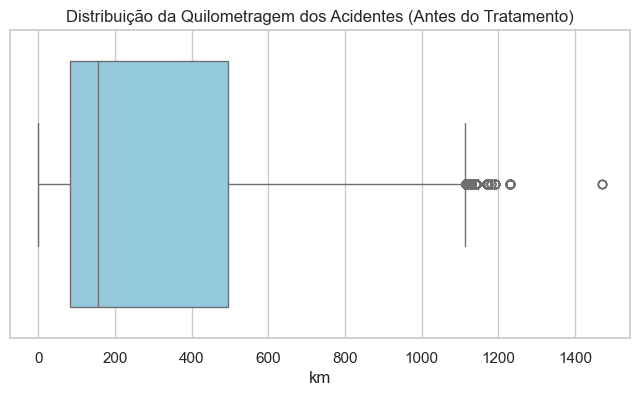

Total de registros originais: 52762
Registros mantidos após limpeza do KM: 51053
Registros removidos (Outliers ou Inválidos): 1709


In [6]:
# 1. Tratamento agressivo: garante que é string, troca vírgula e força conversão para número
df_prf['km'] = df_prf['km'].astype(str).str.replace(',', '.')
df_prf['km'] = pd.to_numeric(df_prf['km'], errors='coerce')

# 2. Separando apenas os dados válidos para o cálculo do IQR (ignora os NaNs gerados acima)
km_valido = df_prf['km'].dropna()

# 3. Plotando o Boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=km_valido, color='skyblue')
plt.title('Distribuição da Quilometragem dos Acidentes (Antes do Tratamento)')
plt.show()

# 4. Tratamento usando Limites Interquartis (IQR) para o KM
Q1 = km_valido.quantile(0.25)
Q3 = km_valido.quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

# 5. Filtrando a base oficial
# Mantemos apenas os acidentes onde o KM é conhecido (não nulo) e está dentro do limite real
df_prf_limpo = df_prf[(df_prf['km'].notna()) & (df_prf['km'] >= 0) & (df_prf['km'] <= limite_superior)].copy()

print(f"Total de registros originais: {len(df_prf)}")
print(f"Registros mantidos após limpeza do KM: {len(df_prf_limpo)}")
print(f"Registros removidos (Outliers ou Inválidos): {len(df_prf) - len(df_prf_limpo)}")

Exportação da Base Processada

In [8]:
import os

# Criando a pasta de processed caso não exista
os.makedirs('../data/processed', exist_ok=True)

# Salvando a base limpa para o próximo notebook de modelagem
caminho_exportacao = '../data/processed/prf_dnit_limpo_pa_2023_2026.csv'
df_prf_limpo.to_csv(caminho_exportacao, index=False, sep=';', encoding='utf-8')

print(f"Arquivo limpo e consolidado salvo com sucesso em: {caminho_exportacao}")

Arquivo limpo e consolidado salvo com sucesso em: ../data/processed/prf_dnit_limpo_pa_2023_2026.csv
